In [276]:
import functions
import importlib
from matplotlib import pyplot as plt
import cv2
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
importlib.reload(functions)
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [277]:
imagens, imgs_mask, labels = functions.load_and_resize_images()

Total de imagens: 511
Total de labels: 511


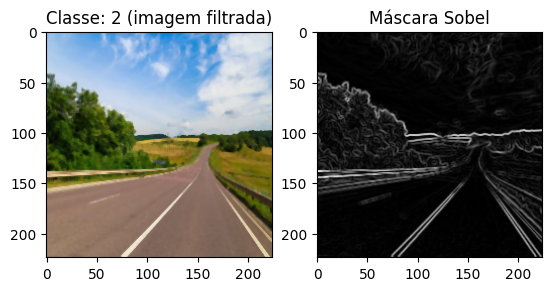

In [278]:
i = 500 # exemplo
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB))
plt.title(f"Classe: {labels[i]} (imagem filtrada)")

plt.subplot(1,2,2)
plt.imshow(imgs_mask[i].squeeze(), cmap="gray")
plt.title("Máscara Sobel")
plt.show()


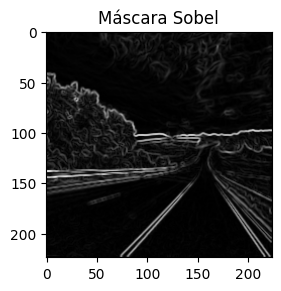

In [279]:
# Defina o limiar (ajuste conforme necessário)
limiar = 15

# imgs_mask está em escala de cinza (resultado do sobel)
imgs_mask_thresh = []
for mask in imgs_mask:
    #_, binary = cv2.threshold(mask, limiar, 255, cv2.THRESH_BINARY)
    #imgs_mask_thresh.append(binary)
    #sobel_norm = cv2.normalize(mask, None, 0, 255, cv2.NORM_MINMAX)
    #imgs_mask_thresh.append(sobel_norm)
    imgs_mask_thresh.append(mask)

imgs_mask_thresh = np.array(imgs_mask_thresh)

plt.subplot(1,2,2)
plt.imshow(imgs_mask_thresh[i].squeeze(), cmap="gray")
plt.title("Máscara Sobel")
plt.show()

In [280]:
# --- Normalização ---
X_imgs = np.array(imagens) / 255.0
X_masks = np.array(imgs_mask_thresh) / 255.0
X_masks = np.expand_dims(X_masks, axis=-1)

# --- Labels ---
y = np.array(labels)

# --- 1. Undersampling para balancear ---
classes = np.unique(y)
min_count = min([np.sum(y == c) for c in classes])

X_img_bal = []
X_mask_bal = []
y_bal = []

for c in classes:
    idx = np.where(y == c)[0]
    np.random.shuffle(idx)
    idx_cut = idx[:min_count]  # corta para o mínimo
    X_img_bal.append(X_imgs[idx_cut])
    X_mask_bal.append(X_masks[idx_cut])
    y_bal.append(y[idx_cut])

# Concatenar tudo
X_imgs = np.concatenate(X_img_bal, axis=0)
X_masks = np.concatenate(X_mask_bal, axis=0)
y = np.concatenate(y_bal, axis=0)

# --- 2. One-hot após balancear ---
y = to_categorical(y, num_classes=3)

# --- 3. Divisão treino/val/test ---
X_img_train, X_img_test, X_mask_train, X_mask_test, y_train, y_test = train_test_split(
    X_imgs, X_masks, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
)

X_img_train, X_img_val, X_mask_train, X_mask_val, y_train, y_val = train_test_split(
    X_img_train, X_mask_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1)
)

In [314]:
# Entrada da imagem RGB
input_img = Input(shape=(X_imgs.shape[1], X_imgs.shape[2], 3))

x1 = Conv2D(16, (3,3), activation='relu')(input_img)
x1 = MaxPooling2D((2,2))(x1)
x1 = Conv2D(8, (3,3), activation='relu')(x1)
x1 = MaxPooling2D((2,2))(x1)
x1 = Flatten()(x1)

# Entrada da máscara (1 canal)
input_mask = Input(shape=(X_masks.shape[1], X_masks.shape[2], 1))

x2 = Conv2D(16, (3,3), activation='relu')(input_mask)
x2 = MaxPooling2D((2,2))(x2)
x2 = Conv2D(8, (3,3), activation='relu')(x2)
x2 = MaxPooling2D((2,2))(x2)
x2 = Flatten()(x2)

# Concatenar as duas saídas
merged = Concatenate()([x1, x2])

# Classificação final
dense = Dense(128, activation='relu')(merged)
dense = Dropout(0.5)(dense)
output = Dense(3, activation='softmax')(dense)

# Modelo final
model = Model(inputs=[input_img, input_mask], outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_62"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_124     │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_125     │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_246 (Conv2D) │ (None, 222, 222,  │        448 │ input_layer_124[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_248 (Conv2D) │ (None, 222, 222,  │        160 │ input_layer_125[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_246   │ (None, 111, 111,  │          0 │ conv2d_246[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_248   │ (None, 111, 111,  │          0 │ conv2d_248[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_247 (Conv2D) │ (None, 109, 109,  │      1,160 │ max_pooling2d_24… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_249 (Conv2D) │ (None, 109, 109,  │      1,160 │ max_pooling2d_24… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_247   │ (None, 54, 54, 8) │          0 │ conv2d_247[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_249   │ (None, 54, 54, 8) │          0 │ conv2d_249[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_124         │ (None, 23328)     │          0 │ max_pooling2d_24… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_125         │ (None, 23328)     │          0 │ max_pooling2d_24… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_62      │ (None, 46656)     │          0 │ flatten_124[0][0… │
│ (Concatenate)       │                   │            │ flatten_125[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_124 (Dense)   │ (None, 128)       │  5,972,096 │ concatenate_62[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_62          │ (None, 128)       │          0 │ dense_124[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_125 (Dense)   │ (None, 3)         │        387 │ dropout_62[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,975,411 (22.79 MB)

 Trainable params: 5,975,411 (22.79 MB)

 Non-trainable params: 0 (0.00 B)

In [315]:
from tensorflow.keras.callbacks import ModelCheckpoint

# Callback para salvar o melhor modelo baseado na acurácia de validação
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',   # nome do arquivo
    monitor='val_accuracy',     # métrica a ser monitorada
    mode='max',                 # queremos o maior valor de acurácia
    save_best_only=True,        # salva apenas o melhor
    verbose=0
)

# Treinamento com callback
history = model.fit(
    [X_img_train, X_mask_train],
    y_train,
    validation_data=([X_img_val, X_mask_val], y_val),
    epochs=100,
    batch_size=32,
    callbacks=[checkpoint],  # adiciona aqui
    verbose=0
)

loss, acc = model.evaluate([X_img_test, X_mask_test], y_test)
print(f"Test Accuracy: {acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5714 - loss: 1.9572
Test Accuracy: 0.57


In [316]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5')

loss, acc = best_model.evaluate([X_img_test, X_mask_test], y_test)
print(f"Best Model Test Accuracy: {acc:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.7143 - loss: 0.5206
Best Model Test Accuracy: 0.71


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


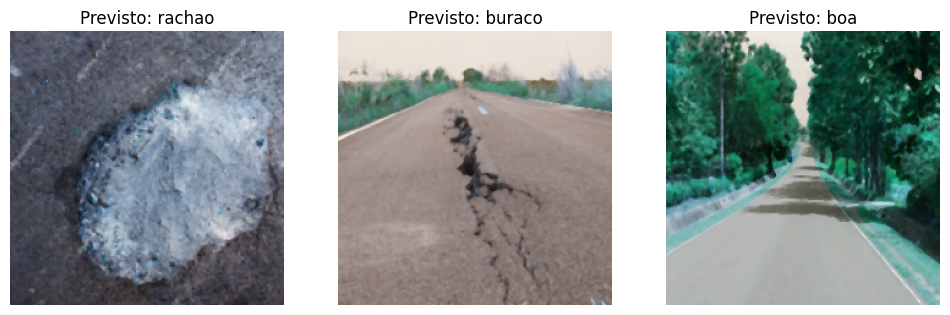

In [321]:
import matplotlib.pyplot as plt
import numpy as np

# Classes
class_names = ["buraco", "rachao", "boa"]

# Seleciona uma imagem aleatória de cada classe
indices = []
for c in range(3):
    idxs = np.where(np.argmax(y_test, axis=1) == c)[0]
    idx = np.random.choice(idxs)  # escolha aleatória
    indices.append(idx)

# Loop para plotar
plt.figure(figsize=(12,4))

for i, idx in enumerate(indices):
    img = X_img_test[idx]
    mask = X_mask_test[idx][..., 0]  # pega canal único da máscara

    # Predição do modelo
    pred = best_model.predict([img[np.newaxis,...], X_mask_test[idx][np.newaxis,...]])
    pred_class = class_names[np.argmax(pred)]

    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Previsto: {pred_class}")
    plt.axis('off')

plt.show()


In [318]:
#for limiar in [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]:
    imgs_mask_thresh = []
    for mask in imgs_mask:
        _, binary = cv2.threshold(mask, limiar, 255, cv2.THRESH_BINARY)
        imgs_mask_thresh.append(binary)

    imgs_mask_thresh = np.array(imgs_mask_thresh)

    # --- Normalização ---
    X_imgs = np.array(imagens) / 255.0
    X_masks = np.array(imgs_mask_thresh) / 255.0
    X_masks = np.expand_dims(X_masks, axis=-1)

    # --- Labels ---
    y = np.array(labels)

    # --- 1. Undersampling para balancear ---
    classes = np.unique(y)
    min_count = min([np.sum(y == c) for c in classes])

    X_img_bal = []
    X_mask_bal = []
    y_bal = []

    for c in classes:
        idx = np.where(y == c)[0]
        np.random.shuffle(idx)
        idx_cut = idx[:min_count]  # corta para o mínimo
        X_img_bal.append(X_imgs[idx_cut])
        X_mask_bal.append(X_masks[idx_cut])
        y_bal.append(y[idx_cut])

    # Concatenar tudo
    X_imgs = np.concatenate(X_img_bal, axis=0)
    X_masks = np.concatenate(X_mask_bal, axis=0)
    y = np.concatenate(y_bal, axis=0)

    # --- 2. One-hot após balancear ---
    y = to_categorical(y, num_classes=3)

    # --- 3. Divisão treino/val/test ---
    X_img_train, X_img_test, X_mask_train, X_mask_test, y_train, y_test = train_test_split(
        X_imgs, X_masks, y, test_size=0.2, random_state=42, stratify=np.argmax(y, axis=1)
    )

    X_img_train, X_img_val, X_mask_train, X_mask_val, y_train, y_val = train_test_split(
        X_img_train, X_mask_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1)
    )

    # Entrada da imagem RGB
    input_img = Input(shape=(X_imgs.shape[1], X_imgs.shape[2], 3))

    x1 = Conv2D(32, (3,3), activation='relu')(input_img)
    x1 = MaxPooling2D((2,2))(x1)
    x1 = Conv2D(64, (3,3), activation='relu')(x1)
    x1 = MaxPooling2D((2,2))(x1)
    x1 = Flatten()(x1)

    # Entrada da máscara (1 canal)
    input_mask = Input(shape=(X_masks.shape[1], X_masks.shape[2], 1))

    x2 = Conv2D(16, (3,3), activation='relu')(input_mask)
    x2 = MaxPooling2D((2,2))(x2)
    x2 = Conv2D(32, (3,3), activation='relu')(x2)
    x2 = MaxPooling2D((2,2))(x2)
    x2 = Flatten()(x2)

    # Concatenar as duas saídas
    merged = Concatenate()([x1, x2])

    # Classificação final
    dense = Dense(128, activation='relu')(merged)
    dense = Dropout(0.5)(dense)
    output = Dense(3, activation='softmax')(dense)

    # Modelo final
    model = Model(inputs=[input_img, input_mask], outputs=output)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(
        [X_img_train, X_mask_train],  # treino
        y_train,
        validation_data=([X_img_val, X_mask_val], y_val),  # validação
        epochs=20,
        batch_size=32,
        verbose=0  # silencia a saída
    )
    loss, acc = model.evaluate([X_img_test, X_mask_test], y_test)

    print(f"Limiar: {limiar} - Test Accuracy: {acc:.2f}")

IndentationError: unexpected indent (1674360736.py, line 2)